In [1]:
import pandas as pd
from pathlib import Path

test = "1"
index = "1"
parameter= "translation_y"
scene = "transmit_2"
camera = "camera1"
csv_path = Path(f"Output/{scene}/{parameter}/{index}/{test}/{camera}_{parameter}_sweep.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)

required_columns = {f"{parameter}", "loss", "analytic_grad", "fd_grad"}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

df.head()

,iter,translation_y,loss,analytic_grad,fd_grad,fd_kind,fd_epsilon
0,0,-0.5,0.411036,0.017678,0.020078,0,0.1
1,1,-0.4,0.413857,0.034676,0.036612,0,0.1
2,2,-0.3,0.418358,0.050635,0.051109,0,0.1
3,3,-0.2,0.424079,0.059150,0.054702,0,0.1
4,4,-0.1,0.429299,0.049441,0.038571,0,0.1


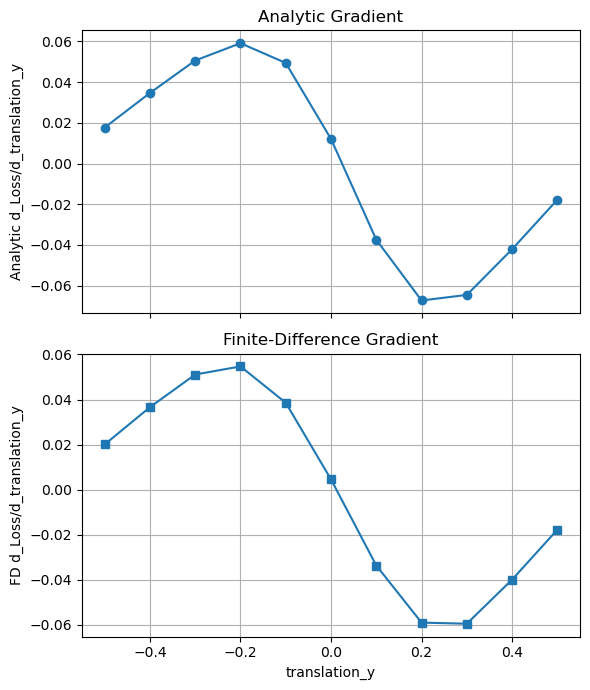

PosixPath('Output/transmit_2/translation_y/1/1/camera1_translation_y_sweep_grad_subplots.png')

In [2]:
import matplotlib.pyplot as plt

NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 7), sharex=True)

# --- Top: Analytic ---
axes[0].plot(df[f"{parameter}"], df["analytic_grad"], marker="o")
axes[0].set_ylabel(f"Analytic d_Loss/d_{parameter}")
axes[0].set_title("Analytic Gradient")
axes[0].grid(True)

# --- Bottom: Finite Difference ---
axes[1].plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s")
axes[1].set_xlabel(f"{parameter}")
axes[1].set_ylabel(f"FD d_Loss/d_{parameter}")
axes[1].set_title("Finite-Difference Gradient")
axes[1].grid(True)

output_png = csv_path.with_name(csv_path.stem + "_grad_subplots.png")
plt.tight_layout()
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

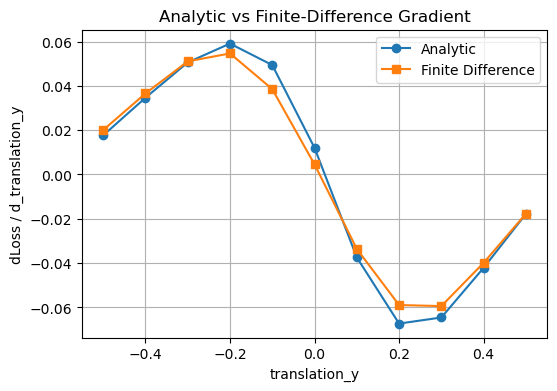

PosixPath('Output/transmit_2/translation_y/1/1/camera1_translation_y_sweep_grad_compare.png')

In [3]:
NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

plt.figure(figsize=(6, 4))

plt.plot(df[f"{parameter}"], df["analytic_grad"], marker="o", label="Analytic")
plt.plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s", label="Finite Difference")

plt.xlabel(f"{parameter}")
plt.ylabel(f"dLoss / d_{parameter}")
plt.title("Analytic vs Finite-Difference Gradient")
plt.grid(True)
plt.legend()

output_png = csv_path.with_name(csv_path.stem + "_grad_compare.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

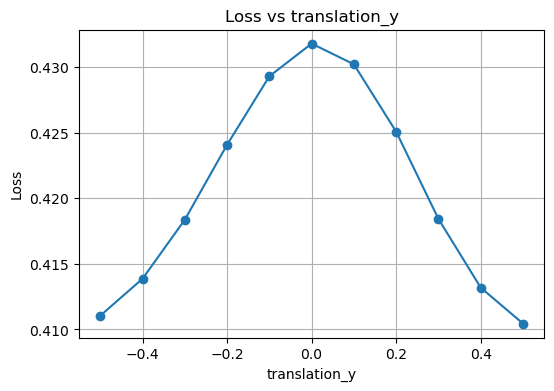

PosixPath('Output/transmit_2/translation_y/1/1/camera1_translation_y_sweep_loss.png')

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(df[f"{parameter}"], df["loss"], marker="o")
plt.xlabel(f"{parameter}")
plt.ylabel("Loss")
plt.title(f"Loss vs {parameter}")
plt.grid(True)

output_png = csv_path.with_name(csv_path.stem + "_loss.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

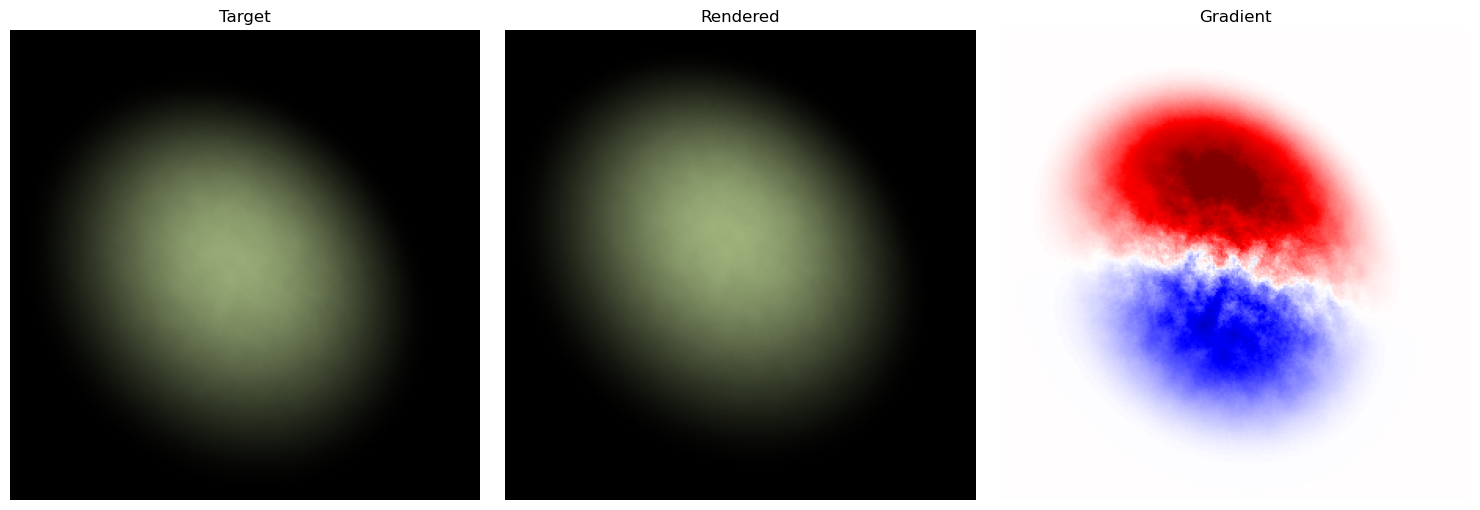

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Paths
iteration = 6
target_image = Path(f"Output/{scene}/{parameter}/{camera}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{index}/{test}/rendered/{iteration}_{camera}.png")
grad_image = Path(f"Output/{scene}/{parameter}/{index}/{test}/grad/{iteration}_{camera}.png")



# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)
img_grad = Image.open(grad_image)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

axes[2].imshow(img_grad)
axes[2].set_title("Gradient")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Output/transmit/translation_z/0/1/rendered/camera2/6_camera2.png


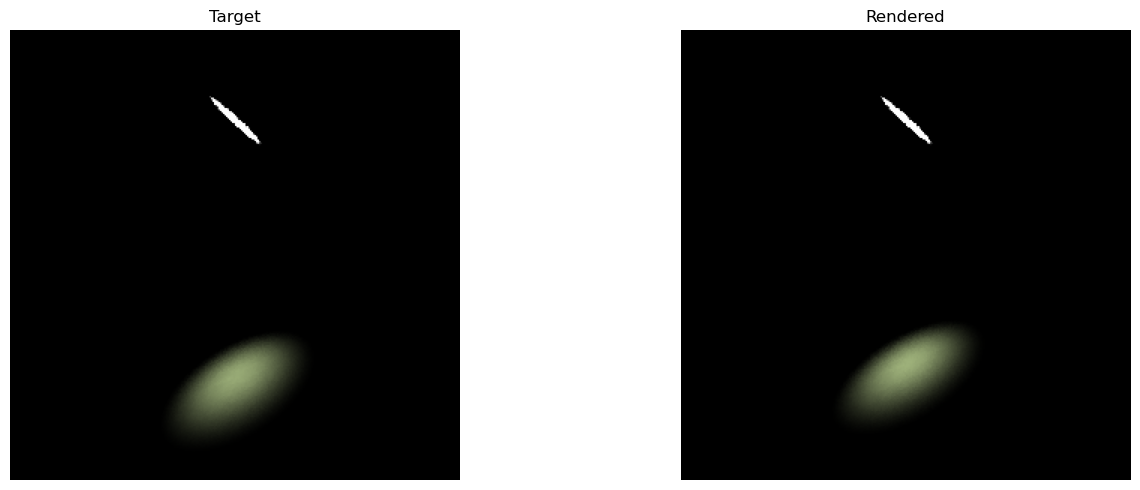

In [6]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

camera_2 = "camera2"
# Paths
iteration = 6
target_image = Path(f"Output/{scene}/{parameter}/{camera_2}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{index}/{test}/rendered/{camera_2}/{iteration}_{camera_2}.png")

print(rendered_test)

# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
print(df["analytic_grad"])
print(df[NUMERICAL_COLUMN])


0    -0.005068
1    -0.004881
2    -0.004193
3    -0.002906
4    -0.001024
5     0.001445
6     0.004481
7     0.007888
8     0.011427
9     0.015010
10    0.018732
Name: analytic_grad, dtype: float64
0    -0.004971
1    -0.004804
2    -0.004161
3    -0.002935
4    -0.001083
5     0.001527
6     0.004629
7     0.008226
8     0.012049
9     0.015887
10    0.019366
Name: fd_grad, dtype: float64
